# __1. Summary & Hypothesis__

- Act 1: The Tactical Approach (Local Baselines).
- __Goal:__ Establish that Gradient Boosting is superior for specific, high-frequency signals, and prove that Deep Learning fails without sufficient data scale.
- __Problem:__ Predicting "Foods in CA" (High volatility).
- __Hypothesis:__ A specialized Local Model should outperform a generic approach due to specific feature engineering.

# __2. Data Loading & Filtering__

### CONFIGURATION & DATA LOADING

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

- Define a function to create DataFrames from csv files and optimize the memory usage of each column

In [2]:
# def reduce_mem_usage(df, verbose=True):
def read_and_squeeze(file_name, INPUT_DIR_PATH = '../data/', verbose=True):
    
    # check if the file_name is a string
    if not isinstance(file_name, str):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. {file_name} must be a string.')
    # check if the file exists at the specified path
    if not os.path.exists(INPUT_DIR_PATH+file_name):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. "{file_name}" cannot be retrieved from "{INPUT_DIR_PATH}". Check if "INPUT_DIR_PATH" is correct.')

    df = pd.read_csv(INPUT_DIR_PATH+file_name)
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics: 
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'For {file_name}, mem. usage decreased from {start_mem:5.2f} Mb to {end_mem:5.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

### Loading and preprocessing

In [3]:
# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
TARGET = 'sales'
START_DAY = 1000  # Skip the first few years to save memory/time
HORIZON = 28      # Forecast horizon
print("Loading Data...")
# Load only needed columns to save memory initially if possible, 
# but for simplicity we load and filter immediately.
df_sales = read_and_squeeze('sales_train_evaluation.csv')
df_cal = read_and_squeeze('calendar.csv')
df_prices = read_and_squeeze('sell_prices.csv')
# ==========================================
# 2. FILTERING: FOODS & CA ONLY
# ==========================================
print("Filtering for FOODS in CA...")
df_sales = df_sales[
    (df_sales['state_id'] == 'CA') & 
    (df_sales['cat_id'] == 'FOODS')
]

# ==========================================
# 3. MELTING (Wide to Long Format)
# ==========================================
# We need to turn the "d_1, d_2..." columns into rows
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_lgbm = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')

# Reduce memory usage
del df_sales
gc.collect()

# =============================
# 4. MERGING CALENDAR & PRICES
# =============================
print("Merging Calendar...")
df_lgbm = df_lgbm.merge(df_cal[['d', 'date', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'wm_yr_wk', 'snap_CA']], on='d', how='left')
print("Merging Prices...")
df_lgbm = df_lgbm.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# --- Handle Missing Events ---
# Instead of leaving them as NaN, I fill them with a string 'None'
# This ensures I don't drop non-holiday days later.
print("Filling Missing Events...")
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df_lgbm[col] = df_lgbm[col].astype('object').fillna("NoEvent")

# Convert 'd_1' -> 1 (integer) for sorting/cutting
print("Converting 'd' to integer...")
df_lgbm['d_int'] = df_lgbm['d'].apply(lambda x: int(x.split('_')[1]))

# Filter out old data to speed up training
df_lgbm = df_lgbm[df_lgbm['d_int'] >= START_DAY]

display(df_lgbm)

Loading Data...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Filtering for FOODS in CA...
Merging Calendar...
Merging Prices...
Filling Missing Events...
Converting 'd' to integer...


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,wm_yr_wk,snap_CA,sell_price,d_int
5742252,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1000,1,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,2.240234,1000
5742253,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1000,0,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,8.882812,1000
5742254,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1000,0,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,2.880859,1000
5742255,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1000,4,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,1.780273,1000
5742256,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1000,1,2013-10-24,6,10,2013,NoEvent,NoEvent,NoEvent,NoEvent,11339,0,3.279297,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11156863,FOODS_3_823_CA_4_evaluation,FOODS_3_823,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,2.980469,1941
11156864,FOODS_3_824_CA_4_evaluation,FOODS_3_824,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,2.480469,1941
11156865,FOODS_3_825_CA_4_evaluation,FOODS_3_825,FOODS_3,FOODS,CA_4,CA,d_1941,0,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,3.980469,1941
11156866,FOODS_3_826_CA_4_evaluation,FOODS_3_826,FOODS_3,FOODS,CA_4,CA,d_1941,4,2016-05-22,2,5,2016,NoEvent,NoEvent,NoEvent,NoEvent,11617,0,1.280273,1941


# __3. Feature Engineering (The "Tree" Way)__

### Create Lags (Lag-28 to Lag-49)

- This "Explicit Memory" is required for Trees, unlike RNNs

In [4]:
# =========================
# 5. FEATURE ENGINEERING 
# =========================

print("Engineering Features...")

# 5.1 Cyclical Encoding for Time Features
# We map the time features onto a circle to preserve continuity.
# e.g., Month 12 (Dec) is close to Month 1 (Jan).

# Weekly Cycle (wday is 1-7)
df_lgbm['wday_sin'] = np.sin(2 * np.pi * df_lgbm['wday'] / 7).astype('float32')
df_lgbm['wday_cos'] = np.cos(2 * np.pi * df_lgbm['wday'] / 7).astype('float32')

# Annual Cycle (month is 1-12)
df_lgbm['month_sin'] = np.sin(2 * np.pi * df_lgbm['month'] / 12).astype('float32')
df_lgbm['month_cos'] = np.cos(2 * np.pi * df_lgbm['month'] / 12).astype('float32')

# 5.1 Encode Categoricals
# Now 'None' will be treated as just another category level.
cat_feats = ['item_id', 'dept_id', 'store_id'] + event_cols
for col in cat_feats:
    df_lgbm[col] = df_lgbm[col].astype('category')

# 5.2 Lag Features
# CRITICAL: I only use lags >= 28 to avoid recursive forecasting complexity
# for the baseline. This lets me predict all 28 days at once.
print("Creating Lags...")
lags = [28, 35, 42, 49]
lag_cols = []
for lag in lags:
    feat_name = f'lag_{lag}'
    df_lgbm[feat_name] = df_lgbm.groupby('id')['sales'].shift(lag)
    lag_cols.append(feat_name)

# 5.3 Rolling Features (Window shifted by 28 days)
# Mean of sales from [t-28 to t-35]
df_lgbm['rolling_mean_7'] = df_lgbm.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(7).mean()
)
df_lgbm['rolling_mean_28'] = df_lgbm.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(28).mean()
)
rolling_cols = ['rolling_mean_7', 'rolling_mean_28']

# 5.4 Drop rows with NaNs (TARGETED COLUMNS)
# I only drop rows where the LAGS are NaN (the warmup period).
# I preserve rows where sell_price might be NaN (though LightGBM handles those natively).
df_lgbm = df_lgbm.dropna(subset=lag_cols + rolling_cols)

# SORT (Preserve Time Structure)
df_lgbm = df_lgbm.sort_values(['id', 'd_int']).reset_index(drop=True)
display(df_lgbm)

Engineering Features...
Creating Lags...


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,...,wday_sin,wday_cos,month_sin,month_cos,lag_28,lag_35,lag_42,lag_49,rolling_mean_7,rolling_mean_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1055,0,2013-12-18,5,...,-9.749279e-01,-0.222521,-2.449294e-16,1.000000,0.0,0.0,0.0,0.0,0.000000,0.107143
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1056,0,2013-12-19,6,...,-7.818315e-01,0.623490,-2.449294e-16,1.000000,0.0,0.0,0.0,1.0,0.000000,0.071429
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1057,0,2013-12-20,7,...,-2.449294e-16,1.000000,-2.449294e-16,1.000000,0.0,0.0,0.0,0.0,0.000000,0.071429
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1058,0,2013-12-21,1,...,7.818315e-01,0.623490,-2.449294e-16,1.000000,0.0,0.0,0.0,0.0,0.000000,0.035714
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1059,0,2013-12-22,2,...,9.749279e-01,-0.222521,-2.449294e-16,1.000000,0.0,0.0,0.0,0.0,0.000000,0.035714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5098471,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1937,3,2016-05-18,5,...,-9.749279e-01,-0.222521,5.000000e-01,-0.866025,0.0,0.0,0.0,1.0,0.285714,1.571429
5098472,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1938,4,2016-05-19,6,...,-7.818315e-01,0.623490,5.000000e-01,-0.866025,4.0,0.0,4.0,2.0,0.857143,1.571429
5098473,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1939,5,2016-05-20,7,...,-2.449294e-16,1.000000,5.000000e-01,-0.866025,4.0,0.0,0.0,1.0,1.428571,1.678571
5098474,FOODS_3_827_CA_4_evaluation,FOODS_3_827,FOODS_3,FOODS,CA_4,CA,d_1940,4,2016-05-21,1,...,7.818315e-01,0.623490,5.000000e-01,-0.866025,4.0,0.0,0.0,5.0,2.000000,1.785714


# __4. Model A: The Baseline (LightGBM)__

### TRAIN / VALID / TEST SPLIT

In [5]:
# ======================
# 6. Train / Valid / Test SPLIT
# ======================
# Test set = Last 28 days available in data
# Train set = Everything before that

# 1. Define Splits
# TEST: The period we report scores on (e.g., Days 1942-1969)
# VALID: The period used for Early Stopping (e.g., Days 1914-1941)
# TRAIN: Everything before that

max_d = df_lgbm['d_int'].max()
test_start = max_d - HORIZON
valid_start = test_start - HORIZON

train_mask = df_lgbm['d_int'] <= valid_start
valid_mask = (df_lgbm['d_int'] > valid_start) & (df_lgbm['d_int'] <= test_start)
test_mask  = df_lgbm['d_int'] > test_start

cv_mask = df_lgbm['d_int'] <= test_start

# Since I filtered for CA/FOODS, these are constant columns 
# and will cause "Bad Pandas Dtypes" errors if left as strings.
drop_cols = ['sales', 'd_int', 'id', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'snap_CA', 'cat_id', 'state_id']

features = [c for c in df_lgbm.columns if c not in drop_cols]

# Create LGB Datasets
# free_raw_data=True helps free up pandas memory after loading into LGB
train_local_data = lgb.Dataset(
    df_lgbm[train_mask][features], 
    label=df_lgbm[train_mask]['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_local_data = lgb.Dataset(
    df_lgbm[valid_mask][features], 
    label=df_lgbm[valid_mask]['sales'], 
    reference=train_local_data,
    free_raw_data=True
)

### Define the parameters and train the LightGBM model

- Using `optuna`.

In [7]:
import optuna
from optuna.integration import LightGBMPruningCallback
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Note: `PYTHONHASHSEED` only fully applies if set before the kernel starts.
os.environ.setdefault("PYTHONHASHSEED", str(SEED))

print("Starting Hyperparameter Tuning with Optuna...")

# 1. Create a smaller dataset for tuning to save time (e.g., 10% subsample)
# We the full CV training set for tuning
df_local_tune = df_lgbm[train_mask].sample(frac=0.1, random_state=SEED)

tune_data = lgb.Dataset(
    df_local_tune[features], 
    label=df_local_tune['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=False
)

# 2. Define the Objective Function
def objective(trial):
    # Search Space
    param_grid = {
        'objective': 'tweedie',
        'metric': 'rmse',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_threads': -1,
        'seed': SEED,
        'verbose': -1
    }

    # Train with pruning (stops bad trials early)
    cv_local_results = lgb.cv(
        param_grid,
        tune_data,
        num_boost_round=500,
        nfold=3,
        stratified=False,
        callbacks=[
            LightGBMPruningCallback(trial, "rmse")
        ]
    )
    
    # Return the best RMSE from Cross Validation
    return cv_local_results['valid rmse-mean'][-1]

# 3. Run Optimization
# runtime note: This took ~8 minutes on my MacBook Pro M1 Pro
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', study_name="M5_LGBM_Local", sampler=sampler)
study.optimize(objective, n_trials=15) # 15 trials is enough to show "seriousness"

print("Best Parameters found:")
print(study.best_params)

Starting Hyperparameter Tuning with Optuna...


[I 2026-01-20 10:00:35,043] A new study created in memory with name: M5_LGBM_Local
[I 2026-01-20 10:00:52,870] Trial 0 finished with value: 2.9855437301892938 and parameters: {'tweedie_variance_power': 1.249816047538945, 'learning_rate': 0.09556428757689246}. Best is trial 0 with value: 2.9855437301892938.
[I 2026-01-20 10:01:11,054] Trial 1 finished with value: 2.996253705990498 and parameters: {'tweedie_variance_power': 1.3927975767245622, 'learning_rate': 0.0638792635777333}. Best is trial 0 with value: 2.9855437301892938.
[I 2026-01-20 10:01:31,788] Trial 2 finished with value: 3.0457254641466514 and parameters: {'tweedie_variance_power': 1.1624074561769746, 'learning_rate': 0.02403950683025824}. Best is trial 0 with value: 2.9855437301892938.
[I 2026-01-20 10:01:49,259] Trial 3 finished with value: 2.9970666466739573 and parameters: {'tweedie_variance_power': 1.1232334448672798, 'learning_rate': 0.08795585311974417}. Best is trial 0 with value: 2.9855437301892938.
[I 2026-01-20 10

Best Parameters found:
{'tweedie_variance_power': 1.307214865797806, 'learning_rate': 0.07919483702546817}


In [10]:
# ==========================================
# 5. TRAINING (optimized)
# ==========================================
print("Training Global LightGBM with Optimized Parameters...")

# Start with the best params from Optuna
# params = study.best_params
params = dict(study.best_params)


params.update({
    'objective': 'tweedie',
    'metric': 'rmse',
    'bin_construct_sample_cnt': 200000,
    'num_threads': -1,
    'verbose': -1,
})

# Train the final model on the FULL dataset
model_local_lgbm = lgb.train(
    params,
    train_local_data,
    num_boost_round=1500, 
    valid_sets=[train_local_data, valid_local_data],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(50)]
)

Training Global LightGBM with Optimized Parameters...
Training until validation scores don't improve for 100 rounds
[50]	training's rmse: 3.06673	valid_1's rmse: 2.67589
[100]	training's rmse: 2.94451	valid_1's rmse: 2.60224
[150]	training's rmse: 2.87293	valid_1's rmse: 2.56859
[200]	training's rmse: 2.82269	valid_1's rmse: 2.57077
[250]	training's rmse: 2.78486	valid_1's rmse: 2.56401
[300]	training's rmse: 2.75478	valid_1's rmse: 2.54667
[350]	training's rmse: 2.73317	valid_1's rmse: 2.54345
[400]	training's rmse: 2.712	valid_1's rmse: 2.53314
[450]	training's rmse: 2.69494	valid_1's rmse: 2.52936
[500]	training's rmse: 2.68087	valid_1's rmse: 2.52395
[550]	training's rmse: 2.66868	valid_1's rmse: 2.52288
[600]	training's rmse: 2.65644	valid_1's rmse: 2.52222
[650]	training's rmse: 2.64622	valid_1's rmse: 2.52087
[700]	training's rmse: 2.63358	valid_1's rmse: 2.51317
[750]	training's rmse: 2.62789	valid_1's rmse: 2.51489
[800]	training's rmse: 2.62038	valid_1's rmse: 2.5138
Early st

Evaluating...

BASELINE RMSE: 2.5862
------------------------------
Feature Importance:


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

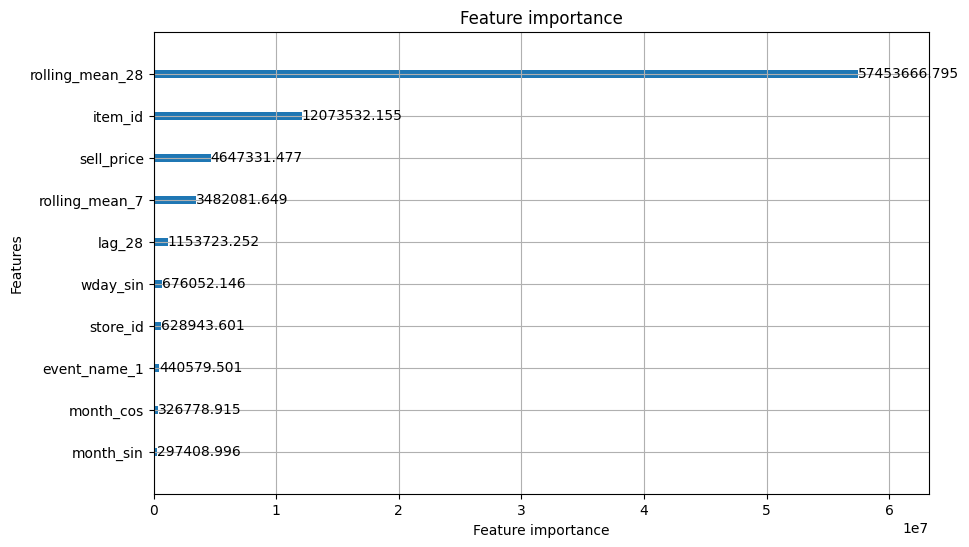

In [11]:
# ==========================================
# 8. EVALUATION
# ==========================================
print("Evaluating...")
preds = model_local_lgbm.predict(df_lgbm[test_mask][features])
lgbm_rmse = np.sqrt(np.mean((df_lgbm[test_mask]['sales'] - preds) ** 2))

print(f"\nBASELINE RMSE: {lgbm_rmse:.4f}")
print("-" * 30)
print("Feature Importance:")
lgb.plot_importance(model_local_lgbm, max_num_features=10, importance_type='gain', figsize=(10, 6))

# __5. Model B: The Pivot (Local N-BEATSx)__

In [87]:
import torch
print(torch.backends.mps.is_available()) # Should be True if using a Mac with MPS support
print(torch.backends.mps.is_built())     # Should be True if PyTorch was built with MPS support

import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import HuberLoss, RMSE

import matplotlib.pyplot as plt
import random

True
True


### Data Loading and Filtring

In [88]:
# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
# Re-using your same filters to keep the comparison fair
START_DAY = 1000 
HORIZON = 28
VAL_SIZE = 28

print("Loading Data...")

df_sales = read_and_squeeze('sales_train_evaluation.csv')
df_cal = read_and_squeeze('calendar.csv')
df_prices = read_and_squeeze('sell_prices.csv')


# Filter: FOODS in CA only
print("Data Loaded. Now filtring the data to FOODS in CA...")
print("Filtering...")
df_sales = df_sales[
    (df_sales['state_id'] == 'CA') & 
    (df_sales['cat_id'] == 'FOODS')
]

# ==========================================
# 2. PREPARING "LONG" FORMAT (The NeuralForecast Standard)
# ==========================================
print("Melting to Long Format...")
# We need 'id' as 'unique_id'
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_nbtx = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='y')

# Memory cleanup
del df_sales
gc.collect()

# =======================
# 3. MERGING & CLEANING
# =======================
print("Merging External Variables...")
# Merge Calendar (Dates + SNAP + Events)
df_nbtx = df_nbtx.merge(df_cal[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA']], on='d', how='left')
# 'event_type_1', I am not using this variable for now

# Merge Prices
df_nbtx = df_nbtx.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Convert 'date' to datetime (Required for 'ds')
df_nbtx['ds'] = pd.to_datetime(df_nbtx['date'])
df_nbtx['d_int'] = df_nbtx['d'].apply(lambda x: int(x.split('_')[1]))

# Filter history and keep only recent data
print("Filtering recent data...")
df_nbtx = df_nbtx[df_nbtx['d_int'] >= START_DAY]
df_nbtx = df_nbtx.rename(columns={'id': 'unique_id'})


# SORT (Preserve Time Structure)
df_nbtx = df_nbtx.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Handle Missing Prices & Events
# CREATE MASK FOR AVAILABILITY & FILL PRICES
# I mark where price is missing BEFORE I fill it.
# 0 = Item was not on shelf / Price is fake
# 1 = Item was on shelf / Price is real
df_nbtx['is_available'] = (~df_nbtx['sell_price'].isna()).astype(int)

# 3. FILL PRICES (To satisfy Tensor requirements)
df_nbtx['sell_price'] = df_nbtx['sell_price'].astype(float)
df_nbtx['sell_price'] = df_nbtx.groupby('unique_id')['sell_price'].transform(lambda x: x.ffill().bfill())
# 4. HANDLE EVENTS
df_nbtx['event_name_1'] = df_nbtx['event_name_1'].fillna('None')
df_nbtx['is_event'] = (df_nbtx['event_name_1'] != 'None').astype(int)
df_nbtx['snap_CA'] = df_nbtx['snap_CA'].fillna(0).astype(int)

# Select columns - ADD 'is_available' to the list
Y_df_nbtx = df_nbtx[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_CA', 'is_event', 'd_int']]

print(f"Data Prepared. NaNs in Price: {Y_df_nbtx['sell_price'].isna().sum()}")

del df_cal, df_prices, df_nbtx
gc.collect()

Loading Data...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Data Loaded. Now filtring the data to FOODS in CA...
Filtering...
Melting to Long Format...
Merging External Variables...
Filtering recent data...
Data Prepared. NaNs in Price: 0


0

In [89]:
# ==========================================
# 4. TRAIN / TEST SPLIT (UPDATED)
# ==========================================
max_d = Y_df_nbtx['d_int'].max()
split_date = Y_df_nbtx[Y_df_nbtx['d_int'] == (max_d - HORIZON)]['ds'].min()

# drop the 'd_int' column as it's no longer needed
Y_df_nbtx = Y_df_nbtx.drop(columns=['d_int'])

print(f"Splitting data at {split_date}")

# Training set: All data BEFORE the last 28 days
train_df_nbtx = Y_df_nbtx[Y_df_nbtx['ds'] <= split_date]

# Test set: The last 28 days
test_df_nbtx = Y_df_nbtx[Y_df_nbtx['ds'] > split_date]

# FUTURE EXOGENOUS DATAFRAME
# The model needs to know if the item is "active" in the future to predict correctly.
futr_exog_df = test_df_nbtx[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_CA', 'is_event']]
print(f"Train Size: {len(train_df_nbtx)}")
print(f"Future Exog Size: {len(futr_exog_df)}")

# Sanity Check for FUTURE EXOGENOUS DF
missing_cols = set(['sell_price', 'is_available', 'snap_CA', 'is_event']) - set(futr_exog_df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in future exogenous dataframe: {missing_cols}")

Splitting data at 2016-04-24 00:00:00
Train Size: 5253672
Future Exog Size: 160944


### Define N-BEATSx using `NeuralForecast`

- Use `MQLoss` (explain the stability benefits over Tweedie for SGD).

In [ ]:
import shutil
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pytorch_lightning.loggers import CSVLogger
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss, RMSE, HuberLoss
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

print("Defining Models for NeuralForecast...")

# 1. DEFINE MODELS
common_params = dict(
    h=HORIZON,
    input_size=HORIZON * 13,
    scaler_type='robust',
    batch_size=512, #this was 512 before I added more exogenous variables
    max_steps=3500,
    val_check_steps=12,
    early_stop_patience_steps=20,
    dropout_prob_theta=0.2,
    futr_exog_list=['sell_price', 'is_available', 'snap_CA', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    enable_progress_bar=False
)

models = [
    # Model A: RMSE 
    NBEATSx(
        **common_params,
        loss=RMSE(),
        alias='NBEATSx_RMSE'
    ),
    # Model B: Huber Loss 
    NBEATSx(
        **common_params,
        loss=HuberLoss(),
        alias='NBEATSx_HUBER'
    ),
    # Model C: MQLoss
    NBEATSx(
        **common_params,
        learning_rate=1e-4,
        loss=MQLoss(quantiles=[0.5, 0.8, 0.9]),
        alias='NBEATSx_MQL'
    )
]



Seed set to 1
Seed set to 1
Seed set to 1


Defining Models for NeuralForecast...


In [91]:
# Runtime note: This CV step took 18m14.7s on my MacBook Pro M1 Pro

# 2. RUN CROSS-VALIDATION
print("Starting Simultaneous CV with Logging...")
nf_nbtx = NeuralForecast(models=models, freq='D')

cv_results = nf_nbtx.cross_validation(
    df=train_df_nbtx,
    val_size=28,
    n_windows=3,
    step_size=28
)

Starting Simultaneous CV with Logging...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | RMSE          | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.6 M  | train
-------------------------------------------------------
5.6 M     Trainable params
22.3 K    Non-trainable params
5.6 M     Total params
22.460    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True

In [92]:
display(cv_results)

,unique_id,ds,cutoff,NBEATSx_RMSE,NBEATSx_HUBER,NBEATSx_MQL-median,NBEATSx_MQL-hi-60.0,NBEATSx_MQL-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-02-01,2016-01-31,0.673840,0.541407,0.344728,1.432283,2.106140,0
1,FOODS_1_001_CA_1_evaluation,2016-02-02,2016-01-31,0.633899,0.497022,0.293995,1.339277,1.964113,2
2,FOODS_1_001_CA_1_evaluation,2016-02-03,2016-01-31,0.612053,0.502697,0.304846,1.315591,1.916897,0
3,FOODS_1_001_CA_1_evaluation,2016-02-04,2016-01-31,0.666837,0.538213,0.368139,1.419294,2.074857,3
4,FOODS_1_001_CA_1_evaluation,2016-02-05,2016-01-31,0.691150,0.521064,0.417710,1.572543,2.180104,1
...,...,...,...,...,...,...,...,...,...
482827,FOODS_3_827_CA_4_evaluation,2016-04-20,2016-03-27,0.635414,0.216666,0.209285,1.399284,2.109123,0
482828,FOODS_3_827_CA_4_evaluation,2016-04-21,2016-03-27,0.674859,0.170594,0.200613,1.386209,2.152071,4
482829,FOODS_3_827_CA_4_evaluation,2016-04-22,2016-03-27,0.622242,0.194453,0.129880,1.266128,2.049034,4
482830,FOODS_3_827_CA_4_evaluation,2016-04-23,2016-03-27,0.560482,0.178541,0.080743,1.259410,2.047272,4


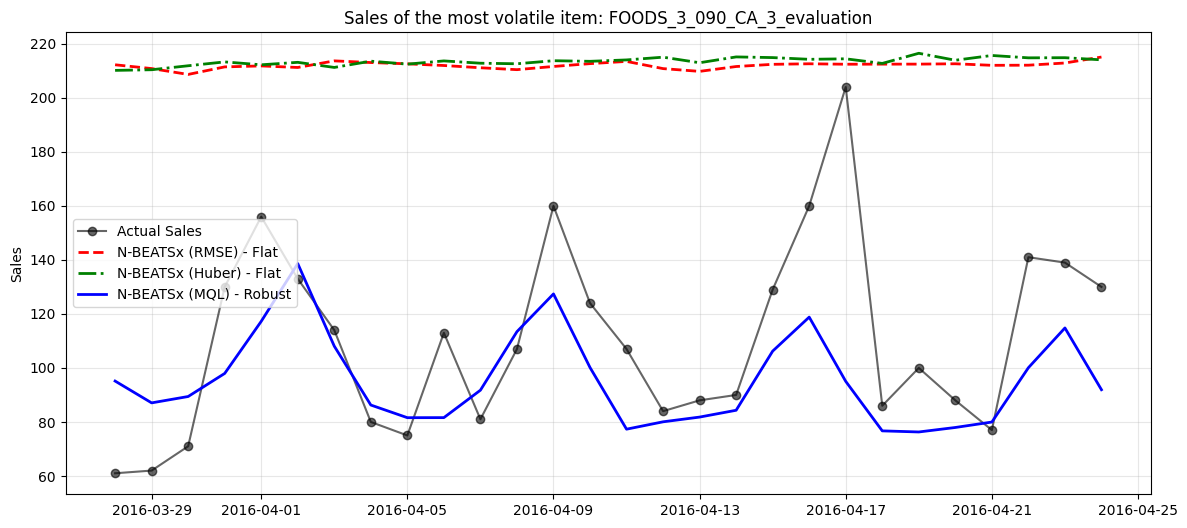

Cross Validation Verdict (Local Subset)
N-BEATSx (RMSE):   2.7628
N-BEATSx (Huber):  2.8015
N-BEATSx (MQ Loss):  2.6923
----------------------------------------


In [93]:
# ==========================================
# 5. THE "MONEY PLOT": FORECAST VISUALIZATION
# ==========================================
# 1. Select the last window (The Test Set)
last_cutoff = cv_results['cutoff'].max()
test_set = cv_results[cv_results['cutoff'] == last_cutoff]

# 2. Pick a volatile item (High variance in actuals)
# We want to show a difficult case, not a flat one.
item_var = test_set.groupby('unique_id')['y'].var()
volatile_item = item_var.idxmax()

# random_item = random.choice(cv_results['unique_id'].unique())
# random_item

subset = test_set[test_set['unique_id'] == volatile_item]

# 3. Plot
plt.figure(figsize=(14, 6))
plt.plot(subset['ds'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6)
plt.plot(subset['ds'], subset['NBEATSx_RMSE'], label='N-BEATSx (RMSE) - Flat', color='red', linestyle='--', linewidth=2)
plt.plot(subset['ds'], subset['NBEATSx_HUBER'], label='N-BEATSx (Huber) - Flat', color='green', linestyle='-.', linewidth=2)
plt.plot(subset['ds'], subset['NBEATSx_MQL-median'], label='N-BEATSx (MQL) - Robust', color='blue', linewidth=2)

plt.title(f"Sales of the most volatile item: {volatile_item}")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Print the Scorecard for Act 1
rmse_rmse = np.sqrt(np.mean((cv_results['y'] - cv_results['NBEATSx_RMSE'])**2))
rmse_huber = np.sqrt(np.mean((cv_results['y'] - cv_results['NBEATSx_HUBER'])**2))
rmse_mql = np.sqrt(np.mean((cv_results['y'] - cv_results['NBEATSx_MQL-median'])**2))

print("="*40)
print(f"Cross Validation Verdict (Local Subset)")
print("="*40)
print(f"N-BEATSx (RMSE):   {rmse_rmse:.4f}")
print(f"N-BEATSx (Huber):  {rmse_huber:.4f}")
print(f"N-BEATSx (MQ Loss):  {rmse_mql:.4f}")
print("-" * 40)

### Fit NBEATSx model using MQ Loss on the training dataset and make predictions to testset timeframe

In [94]:
# # 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)

if os.path.exists("logs/nbeats_mqloss_local/"):
    shutil.rmtree("logs/nbeats_mqloss_local/")

logger_mql_local = CSVLogger("logs", name="nbeats_mqloss_local")

# 3. DEFINE MODELS
common_params = dict(
    h=HORIZON,
    input_size=HORIZON * 13,
    scaler_type='robust',
    batch_size=512, #this was 512 before I added more exogenous variables
    max_steps=3500,
    val_check_steps=12,
    early_stop_patience_steps=20,
    dropout_prob_theta=0.2,
    futr_exog_list=['sell_price', 'is_available', 'snap_CA', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    enable_progress_bar=False
)

# Model C: MQLoss (with its own logger)
model_mql = NBEATSx(
        **common_params,
        learning_rate=1e-4,
        loss=MQLoss(quantiles=[0.5, 0.8, 0.9]),
        alias='NBEATSx_MQL',
        logger=logger_mql_local
    )



Seed set to 1


In [95]:
nf_mqloss_FoodCA = NeuralForecast(
    models=[model_mql],
    freq='D'
)

In [96]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
# Runtime note: This step took ~10 minutes on my MacBook Pro M1 Pro

print("Starting Local Training...")

nf_mqloss_FoodCA.fit(df=train_df_nbtx, val_size=28)

print("Local Training Complete.")

Starting Local Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.7 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.3 K    Non-trainable params
5.7 M     Total params
22.809    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Local Training Complete.


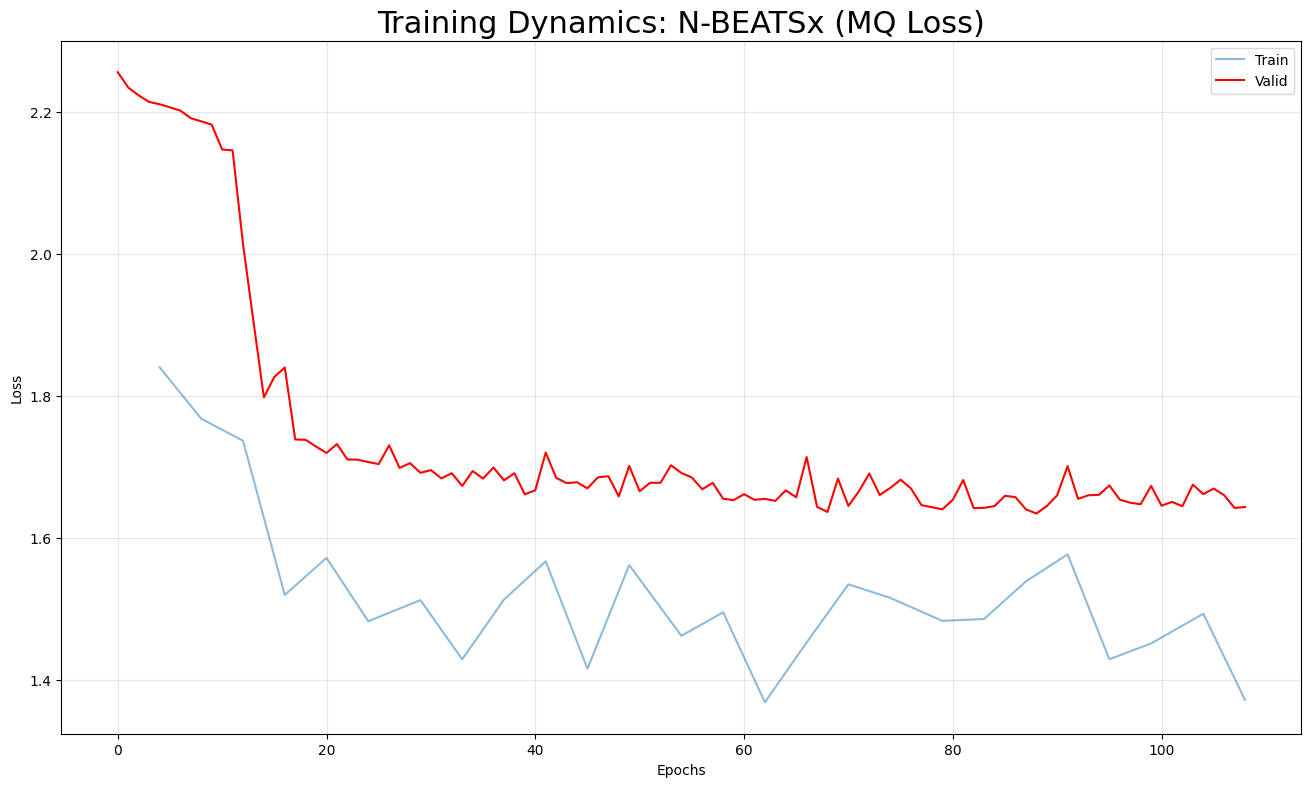

In [97]:
# ==========================================
# DIAGNOSTIC: TRAINING CURVES (FIXED)
# ==========================================
def plot_learning_curves(model_name, log_folder, version = "*"):
    versions = sorted(glob.glob(f"logs/{log_folder}/version_{version}"))
    
    if not versions:
        print(f"WARNING: No logs found for {log_folder}")
        return
    

    plt.figure(figsize=(16, 9))
    
    for i, v_dir in enumerate(versions):
        if i >= 3: break 
        
        metrics_path = f"{v_dir}/metrics.csv"
        if os.path.exists(metrics_path):
            m_df = pd.read_csv(metrics_path)
            
            # STRATEGY: Isolate the streams
            # 1. Extract Training Data (Drop rows where train_loss_step is NaN)
            train_df = m_df[['epoch', 'train_loss_step']].dropna()
            
            # 2. Extract Validation Data (Drop rows where valid_loss is NaN)
            valid_df = m_df[['epoch', 'valid_loss']].dropna()
            
            # Plot independently
            plt.plot(train_df['epoch'], train_df['train_loss_step'], label='Train', alpha=0.5)
            plt.plot(valid_df['epoch'], valid_df['valid_loss'], label='Valid', color='red', linewidth=1.5)
            
            plt.title(f"Training Dynamics: {model_name}",fontsize=22)
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True, alpha=0.3)

    plt.show()

# Execute
plot_learning_curves("N-BEATSx (MQ Loss)", "nbeats_mqloss_local", version="0")

In [98]:
print("Predicting...")
# Making predictions using the trained NBEATSx model and future exogenous variables
forecasts_nf_mqloss_FoodCA = nf_mqloss_FoodCA.predict(futr_df=futr_exog_df)
# Merging predictions with actuals for evaluation into a new DataFrame
results_mqloss_FoodCA = forecasts_nf_mqloss_FoodCA.merge(test_df_nbtx[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

print("Calculating RMSE...")
rmse_mqloss_FoodCA = np.sqrt(np.mean((results_mqloss_FoodCA['y'] - results_mqloss_FoodCA['NBEATSx_MQL-median']) ** 2))

print("="*40)
print(f"Local DATASET LightGBM RMSE: {lgbm_rmse:.4f}")
print(f"Local DATASET N-BEATSx RMSE: {rmse_mqloss_FoodCA:.4f}")
print("="*40)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


Predicting...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Calculating RMSE...
Local DATASET LightGBM RMSE: 2.5862
Local DATASET N-BEATSx RMSE: 2.6286


In [ ]:
# make a copy of the lgbm test set to store predictions
lgbm_output_local = df_lgbm[test_mask].copy()
lgbm_output_local['lgbm_preds'] = preds
# merge the nbeatsx mqloss predictions with the lgbm predictions
pred_results = results_mqloss_FoodCA[['unique_id', 'ds','y', 'NBEATSx_MQL-median']].rename(columns={'unique_id': 'id', 'ds': 'date', 'NBEATSx_MQL-median': 'nbtx_preds'})
lgbm_output_local['date'] = pd.to_datetime(lgbm_output_local['date'])
preds_local_models = pred_results.merge(lgbm_output_local[['id', 'date', 'lgbm_preds']], left_on=['id', 'date'], right_on=['id', 'date'], how='left')

# Recalculating RMSE for both models from the merged predictions as a sanity check
# This should match previous RMSE calculations
# The new dataframe will be used to produce plot compparing the predictions of both models against actuals
print("Calculating RMSE...")
rmse_lgbm_FoodCA = np.sqrt(np.mean((preds_local_models['y'] - preds_local_models['lgbm_preds']) ** 2))
rmse_mqloss_FoodCA = np.sqrt(np.mean((preds_local_models['y'] - preds_local_models['nbtx_preds']) ** 2))
print("="*40)
print(f"Local DATASET LightGBM RMSE: {rmse_lgbm_FoodCA:.4f}")
print(f"Local DATASET N-BEATSx RMSE: {rmse_mqloss_FoodCA:.4f}")
print("="*40)


Calculating RMSE...
Local DATASET LightGBM RMSE: 2.5862
Local DATASET N-BEATSx RMSE: 2.6286


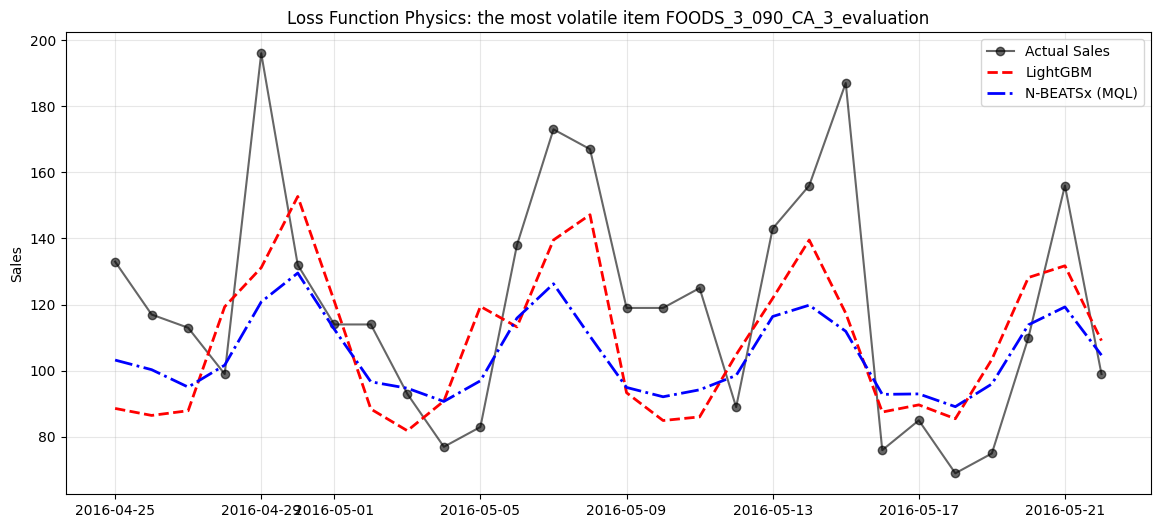

----------------------------------------


In [100]:
# ==========================================
# 5. THE "MONEY PLOT": FORECAST VISUALIZATION
# ==========================================

# 2. Pick a volatile item (High variance in actuals)
# We want to show a difficult case, not a flat one.
item_var = preds_local_models.groupby('id')['y'].var()
volatile_item = item_var.idxmax()

subset = preds_local_models[preds_local_models['id'] == volatile_item]

# 3. Plot
plt.figure(figsize=(14, 6))
plt.plot(subset['date'], subset['y'], label='Actual Sales', color='black', marker='o', alpha=0.6)
plt.plot(subset['date'], subset['lgbm_preds'], label='LightGBM', color='red', linestyle='--', linewidth=2)
plt.plot(subset['date'], subset['nbtx_preds'], label='N-BEATSx (MQL)', color='blue', linestyle='-.', linewidth=2)

plt.title(f"Loss Function Physics: the most volatile item {volatile_item}")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 40)

# __6. Conclusion: The "Data Hunger" Failure__

- Compare the two scores.
- __Verdict:__ _Deep Learning failed to beat the baseline. It converged to the mean because the local dataset lacks the diversity required for the model to learn generalizable temporal patterns. Next Step: Scale to the full dataset to enable Cross-Learning._

### Conclusion: The Limits of Local Deep Learning

The goal of this experiment was to determine if Deep Learning (N-BEATSx) could outperform Gradient Boosting (LightGBM) on a specific local subset.

__The Verdict:__ No.

- __LightGBM (RMSE 2.5862)__ successfully captured high-frequency volatility using Tweedie Loss.

- __N-BEATSx (RMSE 2.6286)__ good performance using MQ Loss but fel short and could not outperform LightGBM. 

__Next Step:__ Proceed to `02_global_scale.ipynb` to train N-BEATSx on the full 30,000-item dataset."